# Magnetotelluric (MT) Time Series Conversion: `.asc` to MTH5

This Jupyter notebook ingests magnetotelluric (MT) raw time-series data generated by the Egbert processing workflow (`ats2asc` output from ADU-07 systems, `.asc` format) and converts them into the standard **MTH5** container format.

**Usage Instructions:** Execute the cells sequentially from top to bottom (`Shift+Enter`). To convert a different dataset or sampling rate, modify exclusively the **"2. Configuration"** cell and rerun the notebook—no further code adjustments are required.

## Input File Structure

1. **`.asc` Files** — ASCII text files without headers, featuring space-delimited columns of variable width. Typically containing 5 numerical columns corresponding to electromagnetic channels ($E_x, E_y, H_x, H_y, H_z$). Values represent **raw uncalibrated digital counts** (integers). The sampling rate is embedded directly into the filename immediately preceding the letter **`H`** (e.g., `..._512H.asc`).

2. **`.clk` Files** — Metadata files consisting of 3 lines: 
   - (1) Sampling interval $\Delta t$ in seconds (true sampling frequency derived from the instrument clock: $f_{s} = 1/\Delta t$).
   - (2) Start timestamp formatted as `"YY MM DD HH MM SS"`.
   - (3) Clock check repetition of the start time. 
   This file provides the necessary temporal reference since raw `.asc` files lack internal timestamps or headers.

---

## Units and Calibration

The values within the `.asc` files are raw A/D converter digital counts (typically on the order of $10^5$–$10^6$) and are **not** scaled to physical units ($\text{mV/km}$ or $\text{nT}$). Conversion to physical units requires instrument calibration factors (e.g., channel gain, dipole length for electric fields, and induction coil response curves). 

By default, this workflow stores data within the MTH5 archive as `"digital counts"`, a standard and robust practice allowing raw data preservation and subsequent calibration application during processing. If calibration factors are available, populate the `CALIBRATION` dictionary within the configuration cell.

---

## Diagnostic

The **"5. Channel Quality Control & Sanity Diagnostics"** cell automatically performs diagnostics (printing metrics and generating comparison plots) for any dataset processed. Always inspect these diagnostics before proceeding with advanced processing.

## 1. Environment Setup & Dependencies

If any required package is missing, execute the following command in a separate cell: `!pip install mth5 matplotlib`

In [36]:
import re
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from mth5.mth5 import MTH5
from mth5.timeseries import ChannelTS, RunTS
import mt_metadata.timeseries as metadata

print("Dependencies successfully imported.")

Dependencies successfully imported.


## 2. Configuration

**This is typically the only cell that requires modification between different dataset runs.** 
The sampling rate is automatically parsed from the filename and verified against the `.clk` file. Simply update the file paths below.

In [37]:
# Target .asc raw data file (mandatory input).
ASC_FILE = "PTR_T1_BB_091a047_000_512H.asc"

# Corresponding .clk metadata file (provides true dt and start timestamp).
# If set to None, the script attempts to locate a matching .clk file automatically 
# in the same directory; otherwise, it falls back to manual mode (see MANUAL_START_TIME).
CLK_FILE = "PTR91047_000_512H.clk"

# Output MTH5 file path.
OUTPUT_MTH5 = "PTR_T1_BB_091a047_000.mth5"

# Experiment, station, and run identifiers.
SURVEY_ID = "survey_001"          # Survey identifier
STATION_ID = None                 # None = automatically extracted from filename prefix (before '_')
RUN_ID = "001"                    # Acquisition run identifier within the station

# Channel mapping for the 5 columns of the .asc file in their raw file order.
# CAUTION: Verify channel ordering against instrument documentation 
# to avoid mapping errors (refer to the diagnostic note above).
CHANNEL_MAP = ["Ex", "Ey", "Hx", "Hy", "Hz"]

# Channel metadata definition (sensor classification and standard orientation 
# in degrees clockwise from Geographic North) — adjust according to field setup.
CHANNEL_INFO = {
    "Ex": {"type": "electric", "azimuth": 0.0,  "dipole_length_m": 100.0},
    "Ey": {"type": "electric", "azimuth": 90.0, "dipole_length_m": 100.0},
    "Hx": {"type": "magnetic", "azimuth": 0.0,  "dipole_length_m": None},
    "Hy": {"type": "magnetic", "azimuth": 90.0, "dipole_length_m": None},
    "Hz": {"type": "magnetic", "azimuth": 0.0,  "dipole_length_m": None},
}

# OPTIONAL calibration factors to convert digital counts into physical units.
# Leave as None to preserve raw "digital counts" (recommended when gains/sensitivities 
# are unverified). If provided, values are multiplied directly by the time series:
#   Electric: counts * factor -> mV/km
#   Magnetic: counts * factor -> nT
CALIBRATION = {
    "Ex": None,
    "Ey": None,
    "Hx": None,
    "Hy": None,
    "Hz": None,
}

# Manual start timestamp fallback (utilized only if CLK_FILE is None or unresolvable).
# ISO8601 format string, e.g., "2021-12-14T18:59:01+00:00".
MANUAL_START_TIME = None

# Timezone assumption for .clk file timestamps (ADU-07 systems utilizing GPS 
# record in UTC by default). Modify if local time was recorded.
CLK_TIMEZONE = "UTC"

# Overwrite behavior:
# If True (default): Deletes any pre-existing file at OUTPUT_MTH5 prior to creation, 
# ensuring a clean environment and preventing HDF5 group/version conflict errors.
# If False: Attempts to append the current run to an existing MTH5 file 
# (useful strictly for multi-run aggregation within a controlled environment).
OVERWRITE_IF_EXISTS = True

print("Configuration parameters loaded successfully.")

Configuration parameters loaded successfully.


## 3. Parsing and Input/Output Utility Functions

In [38]:
def extract_sample_rate_from_filename(filename: str) -> float:
    """
    Extract the sampling frequency (Hz) from the given filename string.

    Pattern rule: The sampling rate always appears immediately preceding 
    the letter 'H' in the filename (e.g., ..._512H.asc, ..._4096H.asc). 
    We capture the LAST occurrence of <digits>+H to prevent ambiguity 
    from other numeric fields (such as Julian day numbers or run IDs).
    """
    matches = re.findall(r"(\d+)H(?=[_.]|$)", filename)
    if not matches:
        raise ValueError(
            f"Unable to extract sampling rate from filename '{filename}'. "
            f"Expected naming convention matching '..._512H.asc'."
        )
    return float(matches[-1])


def extract_station_from_filename(filename: str) -> str:
    """Extract the station name string, assumed to be the token preceding the first underscore."""
    stem = Path(filename).stem
    return stem.split("_")[0]


def find_matching_clk(asc_path: Path):
    """
    Attempt to locate the corresponding .clk file within the source directory.

    Due to differing naming conventions between .asc and .clk files 
    (e.g., 'PTR_T1_BB_091a047_000_512H.asc' vs 'PTR91047_000_512H.clk'), 
    matching is performed via suffix and station prefix association 
    ('<seq>_<RATE>H'). Returns None if ambiguous or unresolvable, 
    triggering manual mode fallback.
    """
    folder = asc_path.parent
    station = extract_station_from_filename(asc_path.name)
    fs_tag_match = re.search(r"(_\d+_\d+H)\.asc$", asc_path.name)
    if fs_tag_match is None:
        return None
    suffix = fs_tag_match.group(1)  # e.g., "_000_512H"

    candidates = [
        p for p in folder.glob("*.clk")
        if p.name.startswith(station) and p.name.endswith(suffix + ".clk")
    ]
    if len(candidates) == 1:
        return candidates[0]
    return None


def read_clk_file(clk_path: Path, tz: str = "UTC"):
    """
    Parse the .clk file and return a tuple of (dt_seconds, start_time).

    Observed file layout:
        Line 1: Sampling interval dt in scientific notation (e.g., 1.9531250000e-03)
        Line 2: Start timestamp formatted as "YY MM DD HH MM SS"
        Line 3: Duplicate timestamp for hardware clock validation

    Two-digit years are mapped to the 21st century for YY < 70 
    and the 20th century otherwise.
    """
    with open(clk_path, "r") as f:
        lines = [ln.strip() for ln in f.readlines() if ln.strip()]

    if len(lines) < 2:
        raise ValueError(f"Unexpected formatting structure in .clk file '{clk_path}'.")

    dt_seconds = float(lines[0])

    yy, mm, dd, hh, mi, ss = (int(x) for x in lines[1].split())
    year = 2000 + yy if yy < 70 else 1900 + yy
    start_time = pd.Timestamp(
        year=year, month=mm, day=dd, hour=hh, minute=mi, second=ss, tz=tz
    )

    if len(lines) >= 3 and lines[2] != lines[1]:
        warnings.warn(
            f"Line 3 of the .clk file ('{lines[2]}') differs from Line 2 ('{lines[1]}'). "
            f"This may indicate instrument clock drift; utilizing Line 2 as the series start. "
            f"Verify manually if necessary."
        )

    return dt_seconds, start_time


def read_asc_file(asc_path: Path, channel_names):
    """
    Parse the whitespace-delimited, headerless ASCII .asc data file 
    and return a float64 pandas DataFrame with labeled channel columns.
    """
    df = pd.read_csv(asc_path, sep=r"\s+", header=None, dtype=np.int64)

    if df.shape[1] != len(channel_names):
        raise ValueError(
            f"File '{asc_path}' contains {df.shape[1]} columns, whereas "
            f"CHANNEL_MAP specifies {len(channel_names)} channels "
            f"({channel_names}). Please update CHANNEL_MAP accordingly."
        )

    df.columns = channel_names
    # Convert integer digital counts to float64, fulfilling requirements 
    # for mth5/xarray time-series processing and preventing overflow 
    # during potential calibration scalar operations.
    return df.astype(np.float64)


print("Utility functions successfully compiled.")

Utility functions successfully compiled.


## 4. Metadata Extraction & Data Ingestion

In [39]:
asc_path = Path(ASC_FILE)

# --- Extract sampling rate and station ID from filename ---
fs_from_name = extract_sample_rate_from_filename(asc_path.name)
station_id = STATION_ID or extract_station_from_filename(asc_path.name)

# --- Resolve true dt and start time (via .clk file with manual fallback) ---
clk_path = Path(CLK_FILE) if CLK_FILE else find_matching_clk(asc_path)

if clk_path is not None and clk_path.exists():
    dt_seconds, start_time = read_clk_file(clk_path, tz=CLK_TIMEZONE)
    sample_rate = round(1.0 / dt_seconds, 6)
    if not np.isclose(sample_rate, fs_from_name, rtol=1e-3):
        warnings.warn(
            f"Filename-derived sampling rate ({fs_from_name} Hz) "
            f"differs from .clk-derived rate ({sample_rate} Hz). "
            f"Adopting the .clk frequency as the more reliable instrument clock source."
        )
else:
    if MANUAL_START_TIME is None:
        raise ValueError(
            "No .clk file detected or provided, and MANUAL_START_TIME is unassigned. "
            "Unable to establish the time series start epoch."
        )
    warnings.warn(".clk file not found — falling back to MANUAL_START_TIME specification.")
    start_time = pd.Timestamp(MANUAL_START_TIME)
    sample_rate = fs_from_name

print(f"Station Identifier: {station_id}")
print(f"Sampling Rate: {sample_rate} Hz")
print(f"Start Timestamp: {start_time.isoformat()}")

# --- Read raw time-series records ---
df = read_asc_file(asc_path, CHANNEL_MAP)
n_samples = len(df)
duration_s = n_samples / sample_rate

print(f"Loaded Samples: {n_samples} ({duration_s:.2f} seconds of recording duration)")
df.head()

Station Identifier: PTR
Sampling Rate: 512.0 Hz
Start Timestamp: 2021-12-14T18:59:01+00:00
Loaded Samples: 303104 (592.00 seconds of recording duration)


,Ex,Ey,Hx,Hy,Hz
0,386123.0,338585.0,24486.0,-601496.0,1070969.0
1,-85566.0,173679.0,24516.0,-199305.0,-130429.0
2,-517011.0,-55651.0,24518.0,392671.0,-970866.0
3,-754107.0,-233341.0,24562.0,864055.0,-1224325.0
4,-566477.0,-335866.0,24552.0,1218199.0,-485017.0


## 5. Channel Quality Control & Sanity Diagnostics

Computes basic descriptive statistics and plots initial time series segments for each channel. 
Channels exhibiting significantly suppressed standard deviations compared to others (appearing as near-flat traces) 
frequently denote disconnected sensors, channel saturation, or mapping errors — **always inspect these diagnostics before proceeding.**

,mean,std,min,max
Ex,"-24,131.25","525,659.00","-2,602,336.00","2,380,555.00"
Ey,"8,931.91","299,305.50","-2,123,565.00","1,753,763.00"
Hx,"24,611.66",61.35,"23,985.00","25,531.00"
Hy,"299,245.43","837,110.83","-2,561,901.00","3,785,327.00"
Hz,"466,535.82","1,357,470.15","-2,430,292.00","3,213,469.00"


C:\Users\PICHAU\AppData\Local\Temp\ipykernel_13884\2471509991.py:7: UserWarning: Channel 'Hx' has a standard deviation much lower than the others (61.35 vs median 525659.00). This usually indicates a disconnected/saturated sensor or channel out of order -- please check before proceeding with processing.
  warnings.warn(


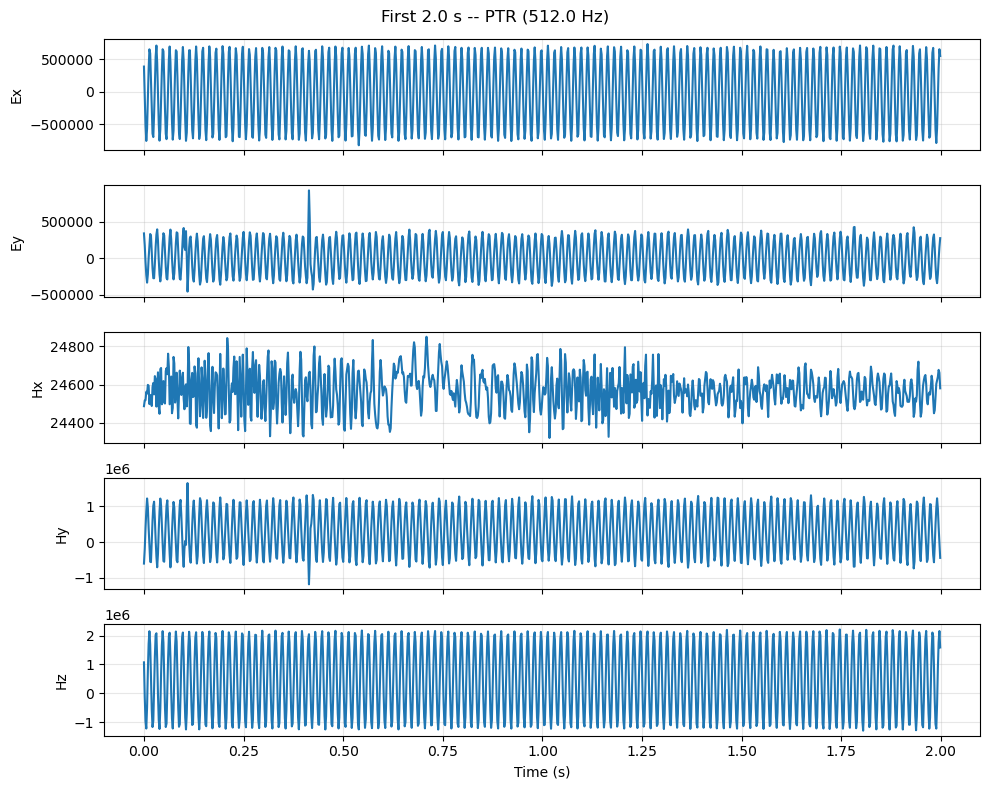

In [40]:
stats = df.describe().T[["mean", "std", "min", "max"]]
display(stats.style.format("{:,.2f}"))

median_std = stats["std"].median()
for ch, std in stats["std"].items():
    if std < 0.05 * median_std:
        warnings.warn(
            f"Channel '{ch}' has a standard deviation much lower than the others "
            f"({std:.2f} vs median {median_std:.2f}). This usually "
            f"indicates a disconnected/saturated sensor or channel out of "
            f"order -- please check before proceeding with processing."
        )

# Plot of the first few seconds of each channel for visual inspection.
n_preview = min(int(sample_rate * 2), n_samples)  # ~2 seconds
fig, axes = plt.subplots(len(CHANNEL_MAP), 1, figsize=(10, 8), sharex=True)
t_preview = np.arange(n_preview) / sample_rate
for ax, ch in zip(axes, CHANNEL_MAP):
    ax.plot(t_preview, df[ch].values[:n_preview])
    ax.set_ylabel(ch)
    ax.grid(alpha=0.3)
axes[-1].set_xlabel("Time (s)")
fig.suptitle(f"First {n_preview/sample_rate:.1f} s -- {station_id} ({sample_rate} Hz)")
plt.tight_layout()
plt.show()

## 6. Assemble the channels (ChannelTS) and the run (RunTS)

In [41]:
def build_channel_ts(component, data, sample_rate, start_time, station_id, run_id, survey_id):
    """
    Builds a ChannelTS (mth5.timeseries) object with the minimum metadata
    required by the MTH5 standard for an electric or magnetic channel.
    """
    info = CHANNEL_INFO[component]
    channel_type = info["type"]  # "electric" or "magnetic"
    calib_factor = CALIBRATION.get(component)

    # Applies calibration if the user provided a factor; otherwise,
    # keeps raw digital counts.
    if calib_factor is not None:
        data = data * calib_factor
        units = "millivolts per kilometer" if channel_type == "electric" else "nanotesla"
    else:
        units = "digital counts"

    if channel_type == "electric":
        ch_metadata = metadata.Electric()
        ch_metadata.dipole_length = info.get("dipole_length_m") or 0.0
    else:
        ch_metadata = metadata.Magnetic()

    ch_metadata.component = component.lower()
    ch_metadata.sample_rate = sample_rate
    ch_metadata.units = units
    ch_metadata.measurement_azimuth = info["azimuth"]
    ch_metadata.time_period.start = start_time.isoformat()
    # time_period.end is automatically recalculated by mth5/RunTS based
    # on the number of samples + sample_rate when the data is
    # assigned to ChannelTS right below.

    return ChannelTS(
        channel_type=channel_type,
        data=data,
        channel_metadata=ch_metadata,
        station_metadata=metadata.Station(id=station_id),
        run_metadata=metadata.Run(id=run_id),
        survey_metadata=metadata.Survey(id=survey_id),
    )


channel_ts_list = [
    build_channel_ts(
        component=ch,
        data=df[ch].to_numpy(),
        sample_rate=sample_rate,
        start_time=start_time,
        station_id=station_id,
        run_id=RUN_ID,
        survey_id=SURVEY_ID,
    )
    for ch in CHANNEL_MAP
]

run_metadata = metadata.Run(id=RUN_ID)
run_metadata.sample_rate = sample_rate

run_ts = RunTS(
    array_list=channel_ts_list,
    run_metadata=run_metadata,
    station_metadata=metadata.Station(id=station_id),
    survey_metadata=metadata.Survey(id=SURVEY_ID),
)

print(f"RunTS assembled with {len(channel_ts_list)} channels: {CHANNEL_MAP}")

2026-09-11T01:09:00.499678-0300 | WARNING | mt_timeseries.run_ts | validate_metadata | line: 1102 | sample rate of dataset 512.0 is different than metadata sample rate 0.0 updating metatdata value to 512.0
RunTS assembled with 5 channels: ['Ex', 'Ey', 'Hx', 'Hy', 'Hz']


## 7. Create the MTH5 file and save the data

In [42]:
Path(OUTPUT_MTH5).parent.mkdir(parents=True, exist_ok=True)

m = MTH5(file_version="0.2.0")
m.open_mth5(OUTPUT_MTH5, mode="a")  # "a": allows adding more runs later

try:
    survey_group = m.add_survey(SURVEY_ID)
    station_group = survey_group.stations_group.add_station(station_id)
    run_group = station_group.add_run(RUN_ID)

    # from_runts creates the channel groups (electric/magnetic) and writes the
    # time series data at once, already populating the
    # station/run/channel metadata from the RunTS.
    run_group.from_runts(run_ts)

    # Updates the file summaries (important for later searches/reports,
    # e.g., m.channel_summary, m.run_summary).
    m.channel_summary.summarize()

    print(f"MTH5 file created successfully: {OUTPUT_MTH5}")
    print(f"Survey: {SURVEY_ID} | Station: {station_id} | Run: {RUN_ID}")
    print(f"Recorded channels: {CHANNEL_MAP}")
finally:
    m.close_mth5()

2026-09-11T01:09:00.586238-0300 | INFO | mth5.groups.survey | add_survey | line: 177 | survey survey_001 already exists, returning existing group.
2026-09-11T01:09:00.662624-0300 | INFO | mth5.groups.base | _add_group | line: 662 | StationGroup PTR already exists, returning existing group.
2026-09-11T01:09:00.724955-0300 | INFO | mth5.groups.base | _add_group | line: 662 | RunGroup 001 already exists, returning existing group.
MTH5 file created successfully: PTR_T1_BB_091a047_000.mth5
Survey: survey_001 | Station: PTR | Run: 001
Recorded channels: ['Ex', 'Ey', 'Hx', 'Hy', 'Hz']
2026-09-11T01:09:02.326203-0300 | INFO | mth5.mth5 | close_mth5 | line: 1035 | Flushing and closing PTR_T1_BB_091a047_000.mth5


## 8. Validate the generated file

Reopen the `.mth5` and check the recorded stations/channels/times/values.

In [43]:
m = MTH5()
m.open_mth5(OUTPUT_MTH5, mode="r")

summary = m.channel_summary.to_dataframe()
display(summary[["survey", "station", "run", "component", "start", "end",
                  "sample_rate", "n_samples", "measurement_type", "units"]])

run_check = m.get_run(station_id, RUN_ID, survey=SURVEY_ID)
first_ch = run_check.get_channel(CHANNEL_MAP[0].lower())
print(f"\nChannel '{CHANNEL_MAP[0]}' -- shape: {first_ch.hdf5_dataset.shape}")
print(f"First values: {first_ch.hdf5_dataset[:5]}")
print(f"start: {first_ch.metadata.time_period.start} | end: {first_ch.metadata.time_period.end}")

m.close_mth5()

,survey,station,run,component,start,end,sample_rate,n_samples,measurement_type,units
0,survey_001,PTR,001,ex,2021-12-14 18:59:01+00:00,2021-12-14 19:08:52.998047+00:00,512.0,303104,electric,digital counts
1,survey_001,PTR,001,ey,2021-12-14 18:59:01+00:00,2021-12-14 19:08:52.998047+00:00,512.0,303104,electric,digital counts
2,survey_001,PTR,001,hx,2021-12-14 18:59:01+00:00,2021-12-14 19:08:52.998047+00:00,512.0,303104,magnetic,digital counts
3,survey_001,PTR,001,hy,2021-12-14 18:59:01+00:00,2021-12-14 19:08:52.998047+00:00,512.0,303104,magnetic,digital counts
4,survey_001,PTR,001,hz,2021-12-14 18:59:01+00:00,2021-12-14 19:08:52.998047+00:00,512.0,303104,magnetic,digital counts



Channel 'Ex' -- shape: (303104,)
First values: [ 386123.  -85566. -517011. -754107. -566477.]
start: 2021-12-14T18:59:01+00:00 | end: 2021-12-14T19:08:52.998047+00:00
2026-09-11T01:09:02.586264-0300 | INFO | mth5.mth5 | close_mth5 | line: 1035 | Flushing and closing PTR_T1_BB_091a047_000.mth5
